# Correlation, Covariance, Distance & Hierarchical Clustering - VN30

This notebook is **not** a pure EDA notebook. It is the intermediate research step after `03_returns_and_validation.ipynb` that:

1. reads `data/processed/return_matrix_clean.csv`
2. computes the correlation matrix and covariance matrix
3. builds the distance matrix
4. runs hierarchical clustering
5. selects the number of clusters
6. exports `ticker_clusters.csv`

The clustering result is used downstream to:

- assign `cluster_id` to each ticker
- support `cluster constraints`
- support diversification constraints based on clusters

It does **not** forecast returns or select stocks directly.

**Input:** `data/processed/return_matrix_clean.csv`  
**Canonical outputs:** `corr_matrix.csv`, `cov_matrix.csv`, `distance_matrix.csv`, `ticker_clusters.csv`  
**Diagnostic / report-support artifacts:** `k_selection_metrics.csv`, `dendrogram_hierarchical_clustering.png`, `cluster_size_barplot.png`


In [1]:
# Import libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

# Safe plotting config with robust sans-serif fallback
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

print("[OK] Library import and plotting config completed")


[OK] Library import and plotting config completed


## Step 1: Read the return matrix and validate the input

The input of this notebook must be a clean `date x ticker` matrix, already based on `log_return`, with no `NaN`, and ready for correlation / covariance / clustering without additional cleaning.


In [2]:
# Setup paths
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS_CLUSTER = PROJECT_ROOT / "reports" / "corr_cluster"
REPORTS_CLUSTER_FIG = REPORTS_CLUSTER / "figures"

file_path = DATA_PROCESSED / "return_matrix_clean.csv"
corr_file = DATA_PROCESSED / "corr_matrix.csv"
cov_file = DATA_PROCESSED / "cov_matrix.csv"
dist_file = DATA_PROCESSED / "distance_matrix.csv"
clusters_file = DATA_PROCESSED / "ticker_clusters.csv"
k_metrics_file = REPORTS_CLUSTER / "k_selection_metrics.csv"
dendrogram_file = REPORTS_CLUSTER_FIG / "dendrogram_hierarchical_clustering.png"
cluster_size_file = REPORTS_CLUSTER_FIG / "cluster_size_barplot.png"

REPORTS_CLUSTER.mkdir(parents=True, exist_ok=True)
REPORTS_CLUSTER_FIG.mkdir(parents=True, exist_ok=True)

EXPECTED_TICKERS = 29

ret = pd.read_csv(file_path, index_col=0, parse_dates=True)

n_nan = int(ret.isna().sum().sum())
is_datetime_index = isinstance(ret.index, pd.DatetimeIndex)

print("=" * 60)
print("INPUT VALIDATION - RETURN MATRIX")
print("=" * 60)
print()
print("1. Matrix shape:")
print(f"   - Shape: {ret.shape}")
print(f"   - Time periods (T): {ret.shape[0]}")
print(f"   - Tickers (N): {ret.shape[1]}")
print()
print("2. NaN check:")
print(f"   - Total NaN values: {n_nan}")
print(f"   - No NaN remaining: {n_nan == 0}")
print()
print("3. Index check:")
print(f"   - DatetimeIndex: {is_datetime_index}")
print(f"   - Date range: {ret.index.min()} -> {ret.index.max()}")
print()
print("4. Universe check:")
print(f"   - Expected tickers: {EXPECTED_TICKERS}")
print(f"   - Actual tickers: {ret.shape[1]}")
print(f"   - Ticker list: {list(ret.columns)}")
print()
print("5. Preview (first 5 rows):")
display(ret.head())

assert is_datetime_index, "return_matrix index must be a DatetimeIndex"
assert n_nan == 0, "return_matrix_clean.csv still contains NaN values"
assert ret.shape[1] == EXPECTED_TICKERS, "Ticker count does not match the expected universe"

print()
print("[OK] Input return matrix is valid for correlation and clustering")


INPUT VALIDATION - RETURN MATRIX

1. Matrix shape:
   - Shape: (1435, 29)
   - Time periods (T): 1435
   - Tickers (N): 29

2. NaN check:
   - Total NaN values: 0
   - No NaN remaining: True

3. Index check:
   - DatetimeIndex: True
   - Date range: 2020-01-03 00:00:00 -> 2025-11-28 00:00:00

4. Universe check:
   - Expected tickers: 29
   - Actual tickers: 29
   - Ticker list: ['ACB', 'BCM', 'BID', 'CTG', 'DGC', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG', 'LPB', 'MBB', 'MSN', 'MWG', 'PLX', 'SAB', 'SHB', 'SSI', 'STB', 'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VRE']

5. Preview (first 5 rows):


,ACB,BCM,BID,CTG,DGC,FPT,GAS,GVR,HDB,HPG,...,TCB,TPB,VCB,VHM,VIB,VIC,VJC,VNM,VPB,VRE
date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,0.000000,-0.010509,-0.004164,-0.009178,-0.016737,-0.017151,0.002045,0.034708,-0.008463,0.006020,...,-0.006247,0.008271,-0.009996,0.003510,-0.007308,0.002735,0.000000,0.003330,-0.007479,0.007252
2020-01-06,-0.022849,-0.010253,-0.019537,0.002125,-0.019887,-0.010628,0.031169,-0.017700,-0.020029,-0.006020,...,-0.025387,-0.014938,-0.027156,-0.021413,-0.017263,-0.007049,-0.013606,-0.007647,-0.022780,-0.027841
2020-01-07,0.000000,-0.027992,0.019537,0.016146,0.019887,0.019241,-0.007120,-0.026132,-0.011628,-0.013374,...,0.006407,0.001671,0.003435,0.004870,0.000000,0.001767,-0.000685,0.009308,0.019773,0.008876
2020-01-08,-0.017094,-0.006836,0.008687,-0.002091,-0.050479,-0.022646,-0.000998,-0.036292,0.000000,-0.009840,...,-0.019347,-0.013446,-0.009009,-0.015669,-0.017566,-0.003537,-0.007568,0.002624,-0.012121,-0.037514
2020-01-09,0.012461,-0.007267,0.052740,0.036318,0.039164,0.014034,-0.018805,0.018829,0.028820,0.023214,...,0.012939,0.008425,0.019244,0.009659,0.007566,0.003537,0.009622,-0.001794,0.031510,0.038985



[OK] Input return matrix is valid for correlation and clustering


## Step 2: Compute correlation and covariance matrices

Off-diagonal statistics in this notebook use only the **upper triangle**, so each ticker pair is counted once instead of counting both symmetric triangles.


In [3]:
print("=" * 60)
print("COMPUTE CORRELATION & COVARIANCE")
print("=" * 60)

corr_matrix = ret.corr()
cov_matrix = ret.cov()

assert np.allclose(corr_matrix.values, corr_matrix.values.T), "corr_matrix is not symmetric"
assert np.allclose(np.diag(corr_matrix), 1.0), "corr_matrix diagonal must be approximately 1"
assert np.allclose(cov_matrix.values, cov_matrix.values.T), "cov_matrix is not symmetric"

mask_upper = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
off_diag_corr = corr_matrix.where(mask_upper).stack()

print()
print("1. Correlation matrix:")
print(f"   - Shape: {corr_matrix.shape}")
print()
print("2. Covariance matrix:")
print(f"   - Shape: {cov_matrix.shape}")
print()
print("3. Off-diagonal correlation statistics (upper triangle only):")
print(f"   - Unique pairs: {len(off_diag_corr)}")
print(f"   - Min: {off_diag_corr.min():.4f}")
print(f"   - Max: {off_diag_corr.max():.4f}")
print(f"   - Mean: {off_diag_corr.mean():.4f}")
print(f"   - Median: {off_diag_corr.median():.4f}")
print(f"   - Std: {off_diag_corr.std():.4f}")
print()
print("4. Correlation matrix preview (5x5):")
print(corr_matrix.iloc[:5, :5])
print()
print("[OK] Correlation and covariance computation completed")


COMPUTE CORRELATION & COVARIANCE

1. Correlation matrix:
   - Shape: (29, 29)

2. Covariance matrix:
   - Shape: (29, 29)

3. Off-diagonal correlation statistics (upper triangle only):
   - Unique pairs: 406
   - Min: 0.1779
   - Max: 0.7974
   - Mean: 0.4356
   - Median: 0.4213
   - Std: 0.1197

4. Correlation matrix preview (5x5):
          ACB       BCM       BID       CTG       DGC
ACB  1.000000  0.348485  0.658787  0.688589  0.383107
BCM  0.348485  1.000000  0.344388  0.353095  0.344354
BID  0.658787  0.344388  1.000000  0.735670  0.364274
CTG  0.688589  0.353095  0.735670  1.000000  0.408454
DGC  0.383107  0.344354  0.364274  0.408454  1.000000

[OK] Correlation and covariance computation completed


In [4]:
# Save correlation and covariance matrices
corr_matrix.to_csv(corr_file)
cov_matrix.to_csv(cov_file)

print("[OK] Saved files:")
print(f"   - {corr_file}")
print(f"   - {cov_file}")


[OK] Saved files:
   - D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\processed\corr_matrix.csv
   - D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\processed\cov_matrix.csv


## Step 3: Build the distance matrix from correlation

Current research formula:

$ d_{ij} = \sqrt{2(1 - \rho_{ij})} $

Interpretation:

- high `corr` -> small `distance`
- low or negative `corr` -> large `distance`

Off-diagonal statistics again use only the **upper triangle**.


In [5]:
print("=" * 60)
print("BUILD DISTANCE MATRIX FROM CORRELATION")
print("=" * 60)

distance_matrix = np.sqrt(2 * (1 - corr_matrix))
distance_matrix = pd.DataFrame(
    distance_matrix, index=corr_matrix.index, columns=corr_matrix.columns
)

assert np.allclose(distance_matrix.values, distance_matrix.values.T), "distance_matrix is not symmetric"
assert np.allclose(np.diag(distance_matrix), 0.0), "distance_matrix diagonal must be 0"
assert (distance_matrix.values >= 0).all(), "distance_matrix contains negative values"

off_diag_dist = distance_matrix.where(mask_upper).stack()

print()
print("1. Distance matrix:")
print(f"   - Shape: {distance_matrix.shape}")
print()
print("2. Off-diagonal distance statistics (upper triangle only):")
print(f"   - Unique pairs: {len(off_diag_dist)}")
print(f"   - Min: {off_diag_dist.min():.4f}")
print(f"   - Max: {off_diag_dist.max():.4f}")
print(f"   - Mean: {off_diag_dist.mean():.4f}")
print(f"   - Median: {off_diag_dist.median():.4f}")
print(f"   - Std: {off_diag_dist.std():.4f}")
print()
print("3. Distance matrix preview (5x5):")
print(distance_matrix.iloc[:5, :5])
print()
print("[OK] Distance matrix construction completed")


BUILD DISTANCE MATRIX FROM CORRELATION

1. Distance matrix:
   - Shape: (29, 29)

2. Off-diagonal distance statistics (upper triangle only):
   - Unique pairs: 406
   - Min: 0.6365
   - Max: 1.2822
   - Mean: 1.0559
   - Median: 1.0758
   - Std: 0.1179

3. Distance matrix preview (5x5):
          ACB       BCM       BID       CTG       DGC
ACB  0.000000  1.141503  0.826091  0.789191  1.110760
BCM  1.141503  0.000000  1.145087  1.137458  1.145116
BID  0.826091  1.145087  0.000000  0.727090  1.127587
CTG  0.789191  1.137458  0.727090  0.000000  1.087701
DGC  1.110760  1.145116  1.127587  1.087701  0.000000

[OK] Distance matrix construction completed


In [6]:
# Save distance matrix
distance_matrix.to_csv(dist_file)

print(f"[OK] Saved file: {dist_file}")


[OK] Saved file: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\processed\distance_matrix.csv


## Step 4: Hierarchical clustering

The research setup keeps the clustering method fixed:

- algorithm: `hierarchical clustering`
- linkage method: `Ward linkage`

The variable evaluated in this notebook is the number of clusters `K`.


In [7]:
print("=" * 60)
print("HIERARCHICAL CLUSTERING")
print("=" * 60)

dist_condensed = squareform(distance_matrix.values, checks=True)
expected_pairs = distance_matrix.shape[0] * (distance_matrix.shape[0] - 1) // 2

print()
print("1. Condensed distance:")
print(f"   - Shape: {dist_condensed.shape}")
print(f"   - Number of pairs: {len(dist_condensed)} (= {expected_pairs})")

Z = linkage(dist_condensed, method="ward")

print()
print("2. Linkage matrix:")
print(f"   - Shape: {Z.shape}")
print("   - Method: ward")
print()
print("[OK] Hierarchical clustering completed")


HIERARCHICAL CLUSTERING

1. Condensed distance:
   - Shape: (406,)
   - Number of pairs: 406 (= 406)

2. Linkage matrix:
   - Shape: (28, 4)
   - Method: ward

[OK] Hierarchical clustering completed


## Step 5: Evaluate candidate values of `K` with multiple criteria

The notebook still sweeps `K` from `2` to `10` and still computes `silhouette_score` on the **precomputed distance matrix**. However, `silhouette` is not treated as the only criterion for choosing `K`.

In this research setup, clustering is used to create `cluster_id` for downstream `cluster constraints` and diversification constraints based on clusters. Because of that, the choice of `K` should balance:

- `silhouette_score`
- cluster fragmentation
- cluster balance
- interpretability and practical usability for portfolio optimization

The range `K = 3..6` receives closer attention because it often produces a more compact structure that is easier to interpret and more useful for the downstream use case.


In [8]:
print("=" * 60)
print("EVALUATE CANDIDATE K VALUES")
print("=" * 60)

candidate_k = range(2, 11)
shortlist_focus_values = {3, 4, 5, 6}
total_tickers = distance_matrix.shape[0]
results = []

for k in candidate_k:
    labels = fcluster(Z, k, criterion="maxclust")
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    sil = silhouette_score(distance_matrix.values, labels, metric="precomputed")

    clusters_with_size_lt_3 = int((cluster_sizes < 3).sum())
    singleton_clusters = int((cluster_sizes == 1).sum())
    largest_cluster_ratio = float(cluster_sizes.max() / total_tickers)
    is_candidate_balanced = bool(
        singleton_clusters == 0
        and clusters_with_size_lt_3 == 0
        and largest_cluster_ratio <= 0.45
    )

    results.append(
        {
            "k": k,
            "silhouette_score": float(sil),
            "n_clusters_realized": int(len(np.unique(labels))),
            "min_cluster_size": int(cluster_sizes.min()),
            "max_cluster_size": int(cluster_sizes.max()),
            "clusters_with_size_lt_3": clusters_with_size_lt_3,
            "singleton_clusters": singleton_clusters,
            "largest_cluster_ratio": largest_cluster_ratio,
            "is_candidate_balanced": is_candidate_balanced,
            "is_shortlist_focus": bool(k in shortlist_focus_values),
        }
    )

k_eval = pd.DataFrame(results).sort_values("k").reset_index(drop=True)
silhouette_best = float(k_eval["silhouette_score"].max())
silhouette_tolerance = 0.003
k_eval["silhouette_gap_from_best"] = silhouette_best - k_eval["silhouette_score"]

shortlist_focus = k_eval[k_eval["is_shortlist_focus"]].copy().reset_index(drop=True)
near_best = k_eval[
    k_eval["silhouette_score"] >= silhouette_best - silhouette_tolerance
].copy().reset_index(drop=True)

preferred_pool = near_best[near_best["is_shortlist_focus"]].copy()
if preferred_pool.empty:
    preferred_pool = near_best.copy()

selected_pool = preferred_pool.sort_values(
    [
        "singleton_clusters",
        "clusters_with_size_lt_3",
        "is_candidate_balanced",
        "largest_cluster_ratio",
        "silhouette_score",
        "k",
    ],
    ascending=[True, True, False, True, False, True],
).reset_index(drop=True)

best_row = selected_pool.iloc[0]
best_k = int(best_row["k"])
best_silhouette = float(best_row["silhouette_score"])

k_eval_export = k_eval[
    [
        "k",
        "silhouette_score",
        "n_clusters_realized",
        "min_cluster_size",
        "max_cluster_size",
        "clusters_with_size_lt_3",
        "singleton_clusters",
        "largest_cluster_ratio",
        "is_candidate_balanced",
        "is_shortlist_focus",
        "silhouette_gap_from_best",
    ]
]
k_eval_export.to_csv(k_metrics_file, index=False)

print()
print("1. Full evaluation table for K = 2..10:")
display(k_eval_export)

print()
print("2. Preferred review range for the downstream use case (K = 3..6):")
display(shortlist_focus[
    [
        "k",
        "silhouette_score",
        "silhouette_gap_from_best",
        "min_cluster_size",
        "max_cluster_size",
        "clusters_with_size_lt_3",
        "singleton_clusters",
        "largest_cluster_ratio",
        "is_candidate_balanced",
    ]
])

print()
print(f"3. K values with silhouette close to the best score (tolerance = {silhouette_tolerance:.3f}):")
display(near_best[
    [
        "k",
        "silhouette_score",
        "silhouette_gap_from_best",
        "clusters_with_size_lt_3",
        "singleton_clusters",
        "largest_cluster_ratio",
        "is_candidate_balanced",
        "is_shortlist_focus",
    ]
])

print()
print("4. Multi-criteria ranking inside the final preferred pool:")
display(selected_pool[
    [
        "k",
        "silhouette_score",
        "silhouette_gap_from_best",
        "clusters_with_size_lt_3",
        "singleton_clusters",
        "largest_cluster_ratio",
        "is_candidate_balanced",
    ]
])

k8_row = k_eval[k_eval["k"] == 8]
k4_row = k_eval[k_eval["k"] == 4]

print()
print("5. Selection logic for K:")
print("   - K is not selected from silhouette alone.")
print("   - A K value is downgraded if it creates many singleton clusters or many clusters with size < 3.")
print("   - The range K = 3..6 is preferred because it is more compact, easier to interpret, and more useful for downstream cluster constraints.")
if not k8_row.empty and not k4_row.empty:
    sil_gap = float(k8_row.iloc[0]["silhouette_score"] - k4_row.iloc[0]["silhouette_score"])
    print(
        f"   - In the current snapshot, K = 8 is only {sil_gap:.6f} higher than K = 4 in silhouette"
        + ", but it is clearly more fragmented."
    )
    print(
        f"   - K = 8 has {int(k8_row.iloc[0]['clusters_with_size_lt_3'])} clusters with size < 3 "
        + f"and {int(k8_row.iloc[0]['singleton_clusters'])} singleton clusters."
    )
    print(
        f"   - K = 4 has {int(k4_row.iloc[0]['clusters_with_size_lt_3'])} clusters with size < 3 "
        + f"and {int(k4_row.iloc[0]['singleton_clusters'])} singleton clusters."
    )

print()
print("6. K selected by the multi-criteria rule:")
print(f"   - best_k: {best_k}")
print(f"   - silhouette_score: {best_silhouette:.6f}")
print(f"   - min_cluster_size: {int(best_row['min_cluster_size'])}")
print(f"   - max_cluster_size: {int(best_row['max_cluster_size'])}")
print(f"   - clusters_with_size_lt_3: {int(best_row['clusters_with_size_lt_3'])}")
print(f"   - singleton_clusters: {int(best_row['singleton_clusters'])}")
print(f"   - largest_cluster_ratio: {float(best_row['largest_cluster_ratio']):.4f}")
print(f"   - is_candidate_balanced: {bool(best_row['is_candidate_balanced'])}")

print()
print(f"[OK] Saved K evaluation table: {k_metrics_file}")


EVALUATE CANDIDATE K VALUES

1. Full evaluation table for K = 2..10:


,k,silhouette_score,n_clusters_realized,min_cluster_size,max_cluster_size,clusters_with_size_lt_3,singleton_clusters,largest_cluster_ratio,is_candidate_balanced,is_shortlist_focus,silhouette_gap_from_best
0,2,0.061937,2,12,17,0,0,0.586207,False,False,0.024429
1,3,0.070078,3,7,12,0,0,0.413793,True,True,0.016288
2,4,0.086132,4,3,12,0,0,0.413793,True,True,0.000233
3,5,0.084748,5,1,12,1,1,0.413793,False,True,0.001618
4,6,0.084492,6,1,12,2,1,0.413793,False,True,0.001874
5,7,0.085470,7,1,12,3,2,0.413793,False,False,0.000896
6,8,0.086366,8,1,12,5,3,0.413793,False,False,0.000000
7,9,0.075958,9,1,12,5,3,0.413793,False,False,0.010407
8,10,0.076083,10,1,11,6,4,0.379310,False,False,0.010282



2. Preferred review range for the downstream use case (K = 3..6):


,k,silhouette_score,silhouette_gap_from_best,min_cluster_size,max_cluster_size,clusters_with_size_lt_3,singleton_clusters,largest_cluster_ratio,is_candidate_balanced
0,3,0.070078,0.016288,7,12,0,0,0.413793,True
1,4,0.086132,0.000233,3,12,0,0,0.413793,True
2,5,0.084748,0.001618,1,12,1,1,0.413793,False
3,6,0.084492,0.001874,1,12,2,1,0.413793,False



3. K values with silhouette close to the best score (tolerance = 0.003):


,k,silhouette_score,silhouette_gap_from_best,clusters_with_size_lt_3,singleton_clusters,largest_cluster_ratio,is_candidate_balanced,is_shortlist_focus
0,4,0.086132,0.000233,0,0,0.413793,True,True
1,5,0.084748,0.001618,1,1,0.413793,False,True
2,6,0.084492,0.001874,2,1,0.413793,False,True
3,7,0.085470,0.000896,3,2,0.413793,False,False
4,8,0.086366,0.000000,5,3,0.413793,False,False



4. Multi-criteria ranking inside the final preferred pool:


,k,silhouette_score,silhouette_gap_from_best,clusters_with_size_lt_3,singleton_clusters,largest_cluster_ratio,is_candidate_balanced
0,4,0.086132,0.000233,0,0,0.413793,True
1,5,0.084748,0.001618,1,1,0.413793,False
2,6,0.084492,0.001874,2,1,0.413793,False



5. Selection logic for K:
   - K is not selected from silhouette alone.
   - A K value is downgraded if it creates many singleton clusters or many clusters with size < 3.
   - The range K = 3..6 is preferred because it is more compact, easier to interpret, and more useful for downstream cluster constraints.
   - In the current snapshot, K = 8 is only 0.000233 higher than K = 4 in silhouette, but it is clearly more fragmented.
   - K = 8 has 5 clusters with size < 3 and 3 singleton clusters.
   - K = 4 has 0 clusters with size < 3 and 0 singleton clusters.

6. K selected by the multi-criteria rule:
   - best_k: 4
   - silhouette_score: 0.086132
   - min_cluster_size: 3
   - max_cluster_size: 12
   - clusters_with_size_lt_3: 0
   - singleton_clusters: 0
   - largest_cluster_ratio: 0.4138
   - is_candidate_balanced: True

[OK] Saved K evaluation table: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\corr_cluster\k_selection_metrics.csv


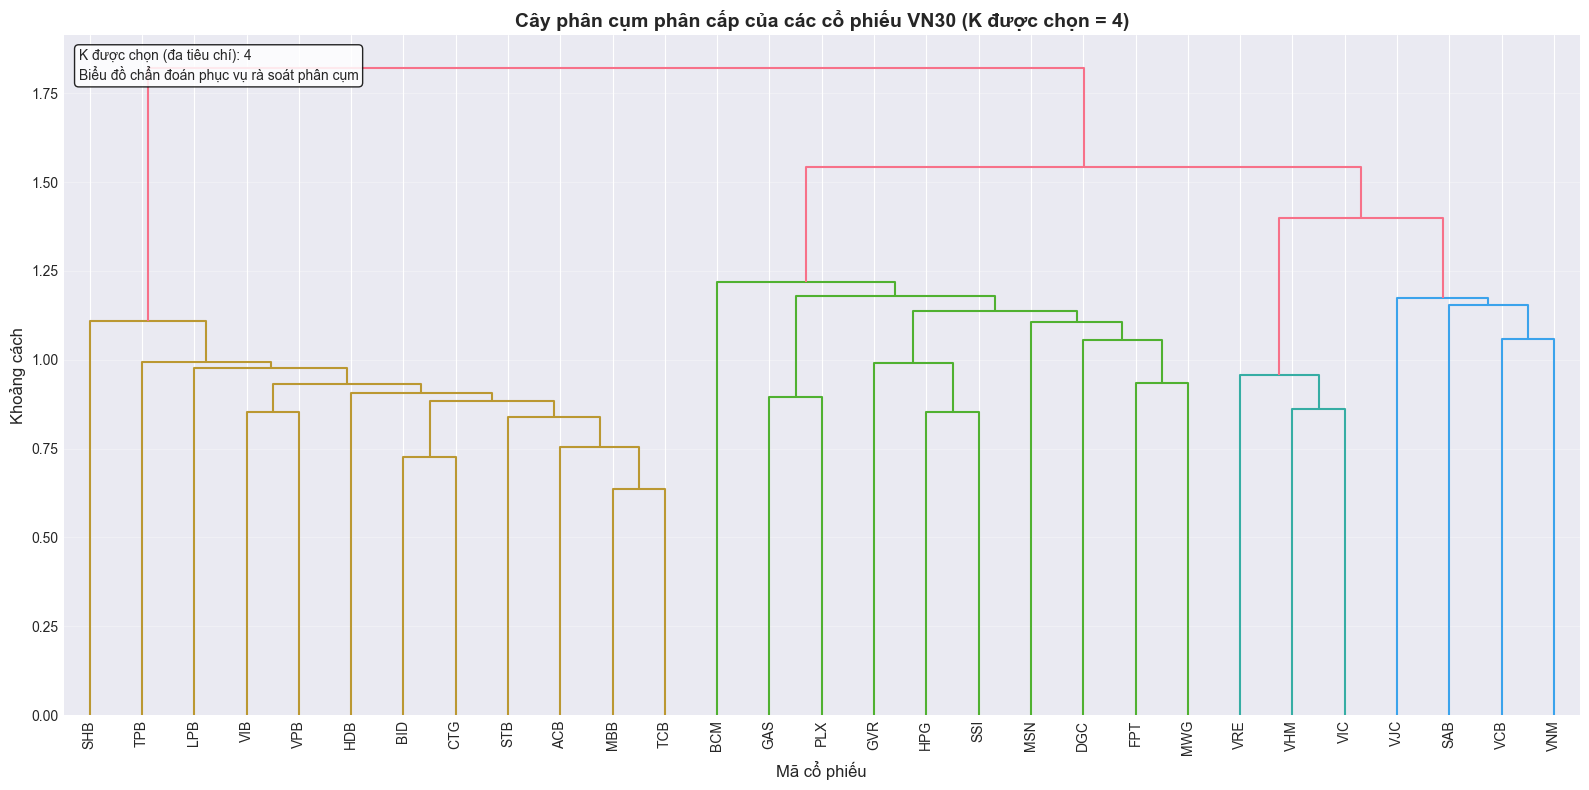

[OK] Saved dendrogram: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\corr_cluster\figures\dendrogram_hierarchical_clustering.png


In [9]:
# Plot and save the diagnostic dendrogram
fig, ax = plt.subplots(figsize=(16, 8))

dendrogram(
    Z,
    labels=distance_matrix.index.tolist(),
    ax=ax,
    leaf_font_size=10,
    leaf_rotation=90,
)

annotation_text = (
    f"K được chọn (đa tiêu chí): {best_k}" + "\n" + "Biểu đồ chẩn đoán phục vụ rà soát phân cụm"
)

ax.set_title(
    f"Cây phân cụm phân cấp của các cổ phiếu VN30 (K được chọn = {best_k})",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Mã cổ phiếu", fontsize=12)
ax.set_ylabel("Khoảng cách", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")
ax.text(
    0.01,
    0.98,
    annotation_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
)

plt.tight_layout()
fig.savefig(dendrogram_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] Saved dendrogram: {dendrogram_file}")


## Step 6: Select the final `K` and build the cluster table

`best_k` should not be chosen mechanically as the value with the highest `silhouette_score`. The notebook applies **multi-criteria selection**:

1. Keep the group of `K` values with `silhouette` close to the best score.
2. Prefer the range `K = 3..6` because it is usually more practical for the downstream use case.
3. Inside that pool, penalize `K` values with too many singleton clusters, too many clusters with size `< 3`, or an excessively large `largest_cluster_ratio`.
4. Choose the final `best_k` by balancing `silhouette`, compact clustering structure, and downstream usability for `cluster constraints`.

The goal of this step is to avoid selecting an overly fragmented `K` just because the silhouette score is slightly higher.


In [10]:
print("=" * 60)
print("SELECT FINAL K AND BUILD CLUSTER TABLE")
print("=" * 60)

cluster_labels = fcluster(Z, best_k, criterion="maxclust")
realized_clusters = np.unique(cluster_labels)
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

ticker_clusters = pd.DataFrame(
    {"ticker": distance_matrix.index, "cluster_id": cluster_labels}
).sort_values(["cluster_id", "ticker"]).reset_index(drop=True)

print()
print("1. Summary of the K selection decision:")
print(f"   - best_k: {best_k}")
print(f"   - silhouette_score: {best_silhouette:.6f}")
print(f"   - n_clusters_realized: {len(realized_clusters)}")
print(f"   - min_cluster_size: {int(cluster_counts.min())}")
print(f"   - max_cluster_size: {int(cluster_counts.max())}")
print(f"   - clusters_with_size_lt_3: {int((cluster_counts < 3).sum())}")
print(f"   - singleton_clusters: {int((cluster_counts == 1).sum())}")
print(f"   - largest_cluster_ratio: {float(cluster_counts.max() / cluster_counts.sum()):.4f}")
print()
print("2. Why this K was selected:")
print("   - Silhouette remains in the acceptable group.")
print("   - The cluster structure is more compact and easier to interpret than the more fragmented alternatives.")
print("   - The result is more suitable for downstream cluster constraints and diversification constraints based on clusters.")
print()
print("3. ticker_clusters DataFrame:")
display(ticker_clusters)
print()
print("[OK] Built the canonical cluster table")


SELECT FINAL K AND BUILD CLUSTER TABLE

1. Summary of the K selection decision:
   - best_k: 4
   - silhouette_score: 0.086132
   - n_clusters_realized: 4
   - min_cluster_size: 3
   - max_cluster_size: 12
   - clusters_with_size_lt_3: 0
   - singleton_clusters: 0
   - largest_cluster_ratio: 0.4138

2. Why this K was selected:
   - Silhouette remains in the acceptable group.
   - The cluster structure is more compact and easier to interpret than the more fragmented alternatives.
   - The result is more suitable for downstream cluster constraints and diversification constraints based on clusters.

3. ticker_clusters DataFrame:


,ticker,cluster_id
0,ACB,1
1,BID,1
2,CTG,1
3,HDB,1
4,LPB,1
5,MBB,1
6,SHB,1
7,STB,1
8,TCB,1
9,TPB,1



[OK] Built the canonical cluster table


In [11]:
# Save ticker_clusters
ticker_clusters.to_csv(clusters_file, index=False)

print(f"[OK] Saved file: {clusters_file}")


[OK] Saved file: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\processed\ticker_clusters.csv


## Step 7: Validate the clustering result

Besides printing cluster counts and ticker membership, this step gives a quick summary of whether the result is usable for downstream `cluster constraints`.


In [12]:
print("=" * 60)
print("VALIDATE CLUSTERING RESULT")
print("=" * 60)

cluster_counts = ticker_clusters["cluster_id"].value_counts().sort_index()
largest_cluster_ratio = float(cluster_counts.max() / cluster_counts.sum())
clusters_with_size_lt_3 = int((cluster_counts < 3).sum())
singleton_clusters = int((cluster_counts == 1).sum())

if singleton_clusters == 0 and clusters_with_size_lt_3 == 0 and largest_cluster_ratio <= 0.45:
    downstream_usability = (
        "The clusters are compact and balanced enough for downstream cluster constraints."
    )
else:
    downstream_usability = (
        "The clusters are still fragmented, so downstream cluster constraints should be applied with caution."
    )

print()
print("1. Cluster quality at best_k:")
print(f"   - best_k: {best_k}")
print(f"   - silhouette_score: {best_silhouette:.6f}")
print(f"   - min_cluster_size: {int(cluster_counts.min())}")
print(f"   - max_cluster_size: {int(cluster_counts.max())}")
print(f"   - clusters_with_size_lt_3: {clusters_with_size_lt_3}")
print(f"   - singleton_clusters: {singleton_clusters}")
print(f"   - largest_cluster_ratio: {largest_cluster_ratio:.4f}")
print()
print("2. Downstream usability note:")
print(f"   - {downstream_usability}")
print()
print("3. Ticker count in each cluster:")
print(cluster_counts)
print()
print("4. Ticker list by cluster:")
for cluster_id in sorted(ticker_clusters["cluster_id"].unique()):
    tickers_in_cluster = ticker_clusters.loc[
        ticker_clusters["cluster_id"] == cluster_id, "ticker"
    ].tolist()
    print()
    print(f"   Cluster {cluster_id} ({len(tickers_in_cluster)} tickers):")
    print(f"   {', '.join(tickers_in_cluster)}")
print()
print("[OK] Clustering validation step completed")


VALIDATE CLUSTERING RESULT

1. Cluster quality at best_k:
   - best_k: 4
   - silhouette_score: 0.086132
   - min_cluster_size: 3
   - max_cluster_size: 12
   - clusters_with_size_lt_3: 0
   - singleton_clusters: 0
   - largest_cluster_ratio: 0.4138

2. Downstream usability note:
   - The clusters are compact and balanced enough for downstream cluster constraints.

3. Ticker count in each cluster:
cluster_id
1    12
2    10
3     3
4     4
Name: count, dtype: int64

4. Ticker list by cluster:

   Cluster 1 (12 tickers):
   ACB, BID, CTG, HDB, LPB, MBB, SHB, STB, TCB, TPB, VIB, VPB

   Cluster 2 (10 tickers):
   BCM, DGC, FPT, GAS, GVR, HPG, MSN, MWG, PLX, SSI

   Cluster 3 (3 tickers):
   VHM, VIC, VRE

   Cluster 4 (4 tickers):
   SAB, VCB, VJC, VNM

[OK] Clustering validation step completed


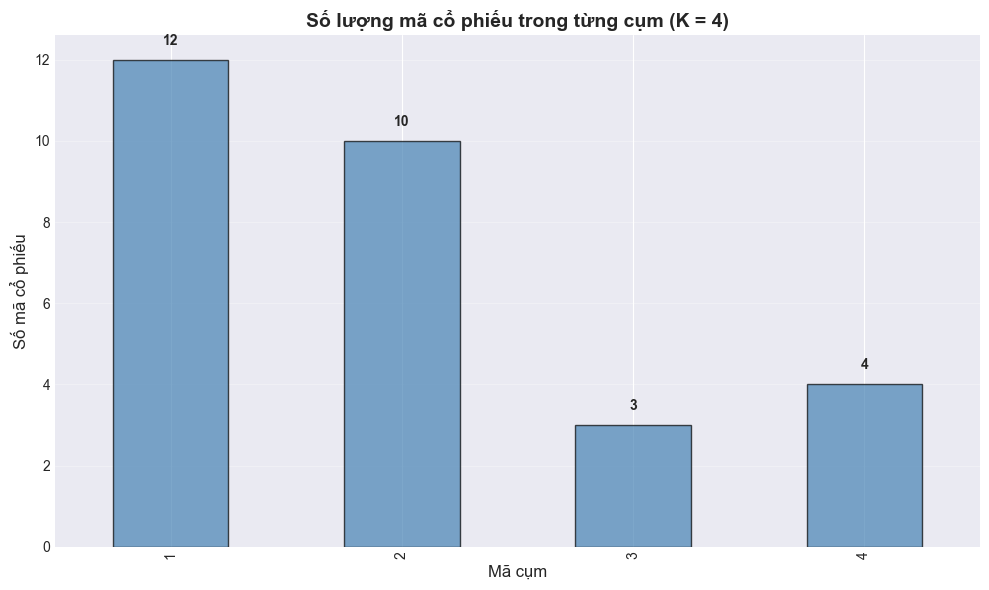

[OK] Saved cluster-size barplot: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\corr_cluster\figures\cluster_size_barplot.png


In [13]:
# Plot and save the diagnostic cluster-size barplot
fig, ax = plt.subplots(figsize=(10, 6))

cluster_counts.plot(kind="bar", ax=ax, color="steelblue", alpha=0.7, edgecolor="black")

ax.set_title(f"Số lượng mã cổ phiếu trong từng cụm (K = {best_k})", fontsize=14, fontweight="bold")
ax.set_xlabel("Mã cụm", fontsize=12)
ax.set_ylabel("Số mã cổ phiếu", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")

for i, v in enumerate(cluster_counts):
    ax.text(i, v + 0.3, str(v), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
fig.savefig(cluster_size_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] Saved cluster-size barplot: {cluster_size_file}")


## Final summary and downstream handoff

This notebook does not choose `K` from `silhouette_score` alone. Instead, `best_k` is selected with a more practical portfolio-oriented rule: keep `silhouette` at an acceptable level while avoiding excessive fragmentation, so the resulting `cluster_id` can be used more reliably for downstream `cluster constraints` and diversification constraints based on clusters.


In [14]:
print("=" * 80)
print("SUMMARY OF CORRELATION, DISTANCE, AND CLUSTERING")
print("=" * 80)
print()
print("INPUT RETURN MATRIX:")
print(f"  - Shape: {ret.shape}")
print(f"  - Date range: {ret.index.min()} -> {ret.index.max()}")
print(f"  - No remaining NaN: {ret.isna().sum().sum() == 0}")
print()
print("MATRICES CREATED:")
print(f"  - corr_matrix shape: {corr_matrix.shape}")
print(f"  - cov_matrix shape: {cov_matrix.shape}")
print(f"  - distance_matrix shape: {distance_matrix.shape}")
print()
print("CLUSTERING METHOD:")
print("  - Hierarchical clustering (Ward linkage)")
print("  - K sweep range: 2..10")
print("  - K selected by multi-criteria selection, not by silhouette alone")
print(f"  - best_k: {best_k}")
print(f"  - silhouette_score at best_k: {best_silhouette:.6f}")
print()
print("DECLARED / EXPORTED ARTIFACTS:")
print(f"  - {corr_file}")
print(f"  - {cov_file}")
print(f"  - {dist_file}")
print(f"  - {clusters_file}")
print(f"  - {k_metrics_file}")
print(f"  - {dendrogram_file}")
print(f"  - {cluster_size_file}")
print()
print("DOWNSTREAM HANDOFF:")
print("  - Next notebook: 05_cluster_insight.ipynb")
print("  - cluster_id will be used for downstream cluster constraints and diversification constraints based on clusters")
print()
print("=" * 80)
print("NOTEBOOK 04 COMPLETED")
print("=" * 80)


SUMMARY OF CORRELATION, DISTANCE, AND CLUSTERING

INPUT RETURN MATRIX:
  - Shape: (1435, 29)
  - Date range: 2020-01-03 00:00:00 -> 2025-11-28 00:00:00
  - No remaining NaN: True

MATRICES CREATED:
  - corr_matrix shape: (29, 29)
  - cov_matrix shape: (29, 29)
  - distance_matrix shape: (29, 29)

CLUSTERING METHOD:
  - Hierarchical clustering (Ward linkage)
  - K sweep range: 2..10
  - K selected by multi-criteria selection, not by silhouette alone
  - best_k: 4
  - silhouette_score at best_k: 0.086132

DECLARED / EXPORTED ARTIFACTS:
  - D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\processed\corr_matrix.csv
  - D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\processed\cov_matrix.csv
  - D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\processed\distance_matrix.csv
  - D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\process